# Exploratory Data Analysis: Position Intensity Data (Embryo 1)

**Dataset**: `data/Ali_embryos/embryo1/position_data-intense.txt`  
**Date**: 2024-12-16  
**Purpose**: Comprehensive EDA of mRNA spot position and intensity data from Drosophila embryo imaging

## Overview
This notebook explores spatial mRNA data containing:
- Nuclear positions and spot counts over time
- mRNA spot positions relative to nuclei
- Intensity measurements across multiple channels

---

## 1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. Load and Inspect the Data

In [2]:
# Load the data
data_path = Path('../data/Ali_embryos/e2/position_data-intense.txt')
df = pd.read_csv(data_path, sep='\t')

# Basic inspection
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nColumn Names:\n{list(df.columns)}")
print(f"\nData Types:\n{df.dtypes}")

Dataset Shape: 104,208 rows × 14 columns

Memory Usage: 23.11 MB

Column Names:
['time', 'nuc', 'num_spots', 'nucx', 'nucy', 'nucz', 'spot', 'spot_type', 'spotx', 'spoty', 'spotz', 'variable', 'channel', 'value']

Data Types:
time         float64
nuc            int64
num_spots      int64
nucx         float64
nucy         float64
nucz         float64
spot           int64
spot_type     object
spotx        float64
spoty        float64
spotz        float64
variable      object
channel        int64
value        float64
dtype: object


In [3]:
# View first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,time,nuc,num_spots,nucx,nucy,nucz,spot,spot_type,spotx,spoty,spotz,variable,channel,value
0,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Sum,2,1.308650e+05
1,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Sum,1,7.220400e+04
2,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Sum of Square,1,3.101470e+07
3,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Sum of Square,2,9.965180e+07
4,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Max,2,1.113000e+03
5,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Max,1,6.350000e+02
6,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Median,1,3.891250e+02
7,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Median,2,7.162500e+02
8,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Center,1,6.010000e+02
9,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.2415,Intensity Center,2,1.001000e+03


In [4]:
# Understand the data structure
print("="*60)
print("DATA STRUCTURE ANALYSIS")
print("="*60)

print("\n📍 Unique values for key categorical columns:")
print(f"  - Time points: {df['time'].nunique()} unique values (range: {df['time'].min():.1f} - {df['time'].max():.1f})")
print(f"  - Nuclei (nuc): {df['nuc'].nunique()} unique nuclei")
print(f"  - Spots: {df['spot'].nunique()} unique spots")
print(f"  - Channels: {sorted(df['channel'].unique())}")
print(f"  - Spot types: {df['spot_type'].unique()}")
print(f"  - Variables (intensity measures): {df['variable'].unique()}")

DATA STRUCTURE ANALYSIS

📍 Unique values for key categorical columns:
  - Time points: 1 unique values (range: 1.0 - 1.0)
  - Nuclei (nuc): 45 unique nuclei
  - Spots: 6513 unique spots
  - Channels: [1, 2]
  - Spot types: ['unknown']
  - Variables (intensity measures): ['Intensity Sum' 'Intensity Sum of Square' 'Intensity Max'
 'Intensity Median' 'Intensity Center' 'Intensity Mean' 'Intensity StdDev'
 'Intensity Min']


## 3. Data Cleaning and Preprocessing

In [5]:
# Check for missing values
print("="*60)
print("MISSING VALUE ANALYSIS")
print("="*60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percent (%)': missing_pct
}).query('`Missing Count` > 0')

if len(missing_df) > 0:
    print("\n⚠️ Columns with missing values:")
    print(missing_df.sort_values('Percent (%)', ascending=False))
else:
    print("\n✅ No missing values detected!")

print(f"\nTotal cells in dataset: {df.size:,}")
print(f"Total missing: {df.isnull().sum().sum():,} ({df.isnull().sum().sum()/df.size*100:.4f}%)")

MISSING VALUE ANALYSIS

✅ No missing values detected!

Total cells in dataset: 1,458,912
Total missing: 0 (0.0000%)


In [6]:
# Check for duplicate rows
print("="*60)
print("DUPLICATE ANALYSIS")
print("="*60)

duplicate_rows = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicate_rows:,} ({duplicate_rows/len(df)*100:.2f}%)")

# Check for duplicate spot-time-variable-channel combinations (should be unique)
key_cols = ['time', 'spot', 'variable', 'channel']
duplicate_keys = df.duplicated(subset=key_cols).sum()
print(f"Duplicate (time, spot, variable, channel) combinations: {duplicate_keys:,}")

if duplicate_keys > 0:
    print("\n⚠️ Warning: Found duplicate key combinations - investigating...")
    duplicates_sample = df[df.duplicated(subset=key_cols, keep=False)].head(10)
    print(duplicates_sample)
else:
    print("✅ No duplicate key combinations found")

DUPLICATE ANALYSIS



Duplicate rows: 0 (0.00%)
Duplicate (time, spot, variable, channel) combinations: 0
✅ No duplicate key combinations found


In [7]:
# Pivot data to wide format for easier analysis of intensity measures
# This creates one row per spot-time observation with intensity measures as columns

print("Creating wide-format dataset for spot-level analysis...")

# Pivot: Create columns for each variable-channel combination
df_wide = df.pivot_table(
    index=['time', 'nuc', 'num_spots', 'nucx', 'nucy', 'nucz', 'spot', 'spot_type', 'spotx', 'spoty', 'spotz'],
    columns=['variable', 'channel'],
    values='value',
    aggfunc='first'
).reset_index()

# Flatten column names
df_wide.columns = [f"{col[0]}_{col[1]}" if col[1] != '' else col[0] for col in df_wide.columns]

print(f"\nWide-format shape: {df_wide.shape[0]:,} rows × {df_wide.shape[1]} columns")
print(f"\nNew columns: {list(df_wide.columns)}")
df_wide.head()

Creating wide-format dataset for spot-level analysis...



Wide-format shape: 6,513 rows × 27 columns

New columns: ['time', 'nuc', 'num_spots', 'nucx', 'nucy', 'nucz', 'spot', 'spot_type', 'spotx', 'spoty', 'spotz', 'Intensity Center_1', 'Intensity Center_2', 'Intensity Max_1', 'Intensity Max_2', 'Intensity Mean_1', 'Intensity Mean_2', 'Intensity Median_1', 'Intensity Median_2', 'Intensity Min_1', 'Intensity Min_2', 'Intensity StdDev_1', 'Intensity StdDev_2', 'Intensity Sum_1', 'Intensity Sum_2', 'Intensity Sum of Square_1', 'Intensity Sum of Square_2']


,time,nuc,num_spots,nucx,nucy,nucz,spot,spot_type,spotx,spoty,spotz,Intensity Center_1,Intensity Center_2,Intensity Max_1,Intensity Max_2,Intensity Mean_1,Intensity Mean_2,Intensity Median_1,Intensity Median_2,Intensity Min_1,Intensity Min_2,Intensity StdDev_1,Intensity StdDev_2,Intensity Sum_1,Intensity Sum_2,Intensity Sum of Square_1,Intensity Sum of Square_2
0,1.0,2,255,24.6899,28.623,7.06172,2534,unknown,21.9331,26.7377,3.24150,601.0,1001.0,635.0,1113.0,407.932,739.350,389.125,716.25,202.0,516.0,93.8903,127.928,72204.0,130865.0,31014700.0,99651800.0
1,1.0,2,255,24.6899,28.623,7.06172,2561,unknown,22.1520,27.0389,3.57781,803.0,809.0,810.0,1319.0,551.011,902.294,545.250,900.25,282.0,527.0,123.8910,144.238,97529.0,159706.0,56456400.0,147784000.0
2,1.0,2,255,24.6899,28.623,7.06172,2584,unknown,24.9524,26.1972,3.06900,414.0,764.0,445.0,1069.0,315.944,810.096,323.125,825.75,158.0,467.0,68.1350,113.398,56238.0,144197.0,18594400.0,119102000.0
3,1.0,2,255,24.6899,28.623,7.06172,2585,unknown,22.8343,26.4044,3.10044,722.0,822.0,870.0,1115.0,611.810,774.857,611.750,760.75,341.0,514.0,105.9860,125.859,102784.0,130176.0,64771400.0,103529000.0
4,1.0,2,255,24.6899,28.623,7.06172,2586,unknown,25.9030,27.0114,3.03330,355.0,753.0,412.0,1083.0,268.091,854.040,261.125,872.25,145.0,513.0,61.2184,107.182,46916.0,149457.0,13233600.0,129653000.0


## 4. Basic Statistical Summary

In [8]:
# Summary statistics for position coordinates (from wide format)
position_cols = ['nucx', 'nucy', 'nucz', 'spotx', 'spoty', 'spotz']

print("="*60)
print("POSITION COORDINATE STATISTICS")
print("="*60)

position_stats = df_wide[position_cols].describe().T
position_stats['range'] = position_stats['max'] - position_stats['min']
position_stats['cv'] = (position_stats['std'] / position_stats['mean'] * 100).round(2)
print("\n")
print(position_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'cv']])

POSITION COORDINATE STATISTICS


        count       mean        std       min       25%       50%       75%  \
nucx   6513.0  20.172994   8.098465  2.598760  13.39590  20.89390  26.37750   
nucy   6513.0  21.471033  10.939529  3.662820  13.37680  20.96830  30.08190   
nucz   6513.0   7.298746   0.232715  6.817600   7.14592   7.29033   7.43939   
spotx  6513.0  20.042960   7.895670  0.017648  14.25520  20.07820  25.96360   
spoty  6513.0  21.370444  11.021644  0.889110  11.97810  21.01920  30.86030   
spotz  6513.0   6.474049   2.715627  2.960170   4.25520   5.71062   8.24212   

            max      range     cv  
nucx   37.77020  35.171440  40.15  
nucy   41.39860  37.735780  50.95  
nucz    7.81723   0.999630   3.19  
spotx  39.86620  39.848552  39.39  
spoty  43.94720  43.058090  51.57  
spotz  14.10500  11.144830  41.95  


In [9]:
# Summary statistics for spot counts per nucleus
print("="*60)
print("SPOT COUNTS PER NUCLEUS STATISTICS")
print("="*60)

# Get unique nucleus-time observations with spot counts
nuc_spot_counts = df_wide.groupby(['time', 'nuc'])['num_spots'].first()
print(f"\nSpots per nucleus summary:")
print(nuc_spot_counts.describe())

# Distribution of spot counts
print(f"\nSpot count distribution (top 10):")
print(nuc_spot_counts.value_counts().head(10))

SPOT COUNTS PER NUCLEUS STATISTICS

Spots per nucleus summary:
count     45.000000
mean     144.733333
std       80.315684
min       20.000000
25%       78.000000
50%      159.000000
75%      211.000000
max      299.000000
Name: num_spots, dtype: float64

Spot count distribution (top 10):
num_spots
235    2
168    2
255    1
20     1
78     1
181    1
21     1
209    1
203    1
211    1
Name: count, dtype: int64


In [10]:
# Summary statistics for intensity values (original long format)
print("="*60)
print("INTENSITY VALUE STATISTICS BY VARIABLE TYPE")
print("="*60)

intensity_stats = df.groupby(['variable', 'channel'])['value'].describe()
print("\n")
print(intensity_stats)

INTENSITY VALUE STATISTICS BY VARIABLE TYPE


                                  count          mean           std  \
variable                channel                                       
Intensity Center        1        6513.0  4.855452e+02  2.125648e+02   
                        2        6513.0  1.634901e+03  6.179854e+02   
Intensity Max           1        6513.0  5.140556e+02  2.200457e+02   
                        2        6513.0  2.156636e+03  7.140290e+02   
Intensity Mean          1        6513.0  3.515458e+02  1.605259e+02   
                        2        6513.0  1.631682e+03  5.797203e+02   
Intensity Median        1        6513.0  3.484452e+02  1.608198e+02   
                        2        6513.0  1.625993e+03  5.796492e+02   
Intensity Min           1        6513.0  1.985910e+02  1.014255e+02   
                        2        6513.0  1.166209e+03  4.673373e+02   
Intensity StdDev        1        6513.0  6.948191e+01  2.848428e+01   
                        2      

## 5. Visualize Position Distributions

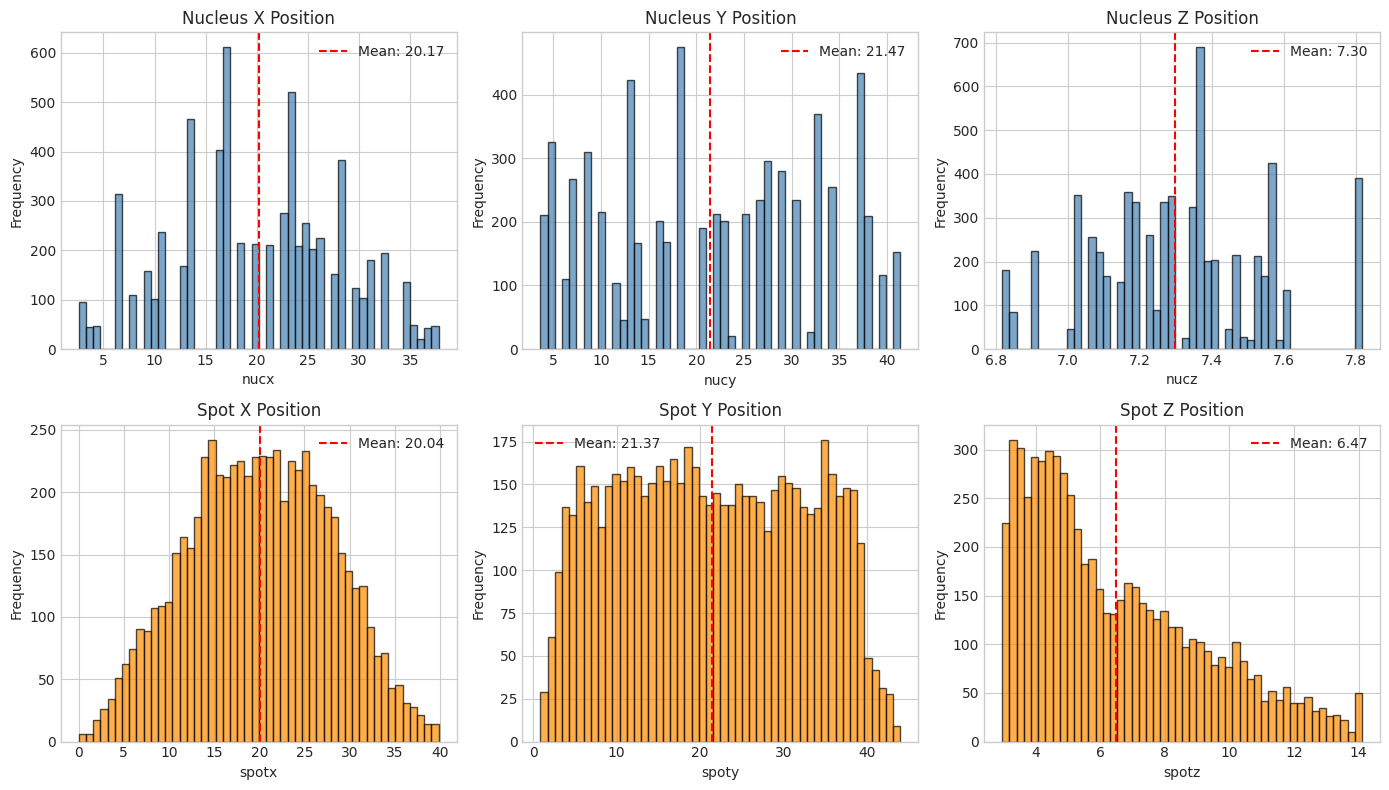

✅ Saved: ../results/intermediate_edgeSpotsRemoved/eda_position_histograms.png


In [ ]:
# Position distribution histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Nucleus positions
for i, (col, ax) in enumerate(zip(['nucx', 'nucy', 'nucz'], axes[0])):
    ax.hist(df_wide[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Nucleus {col.upper()[-1]} Position')
    ax.axvline(df_wide[col].mean(), color='red', linestyle='--', label=f'Mean: {df_wide[col].mean():.2f}')
    ax.legend()

# Spot positions
for i, (col, ax) in enumerate(zip(['spotx', 'spoty', 'spotz'], axes[1])):
    ax.hist(df_wide[col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='darkorange')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Spot {col.upper()[-1]} Position')
    ax.axvline(df_wide[col].mean(), color='red', linestyle='--', label=f'Mean: {df_wide[col].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

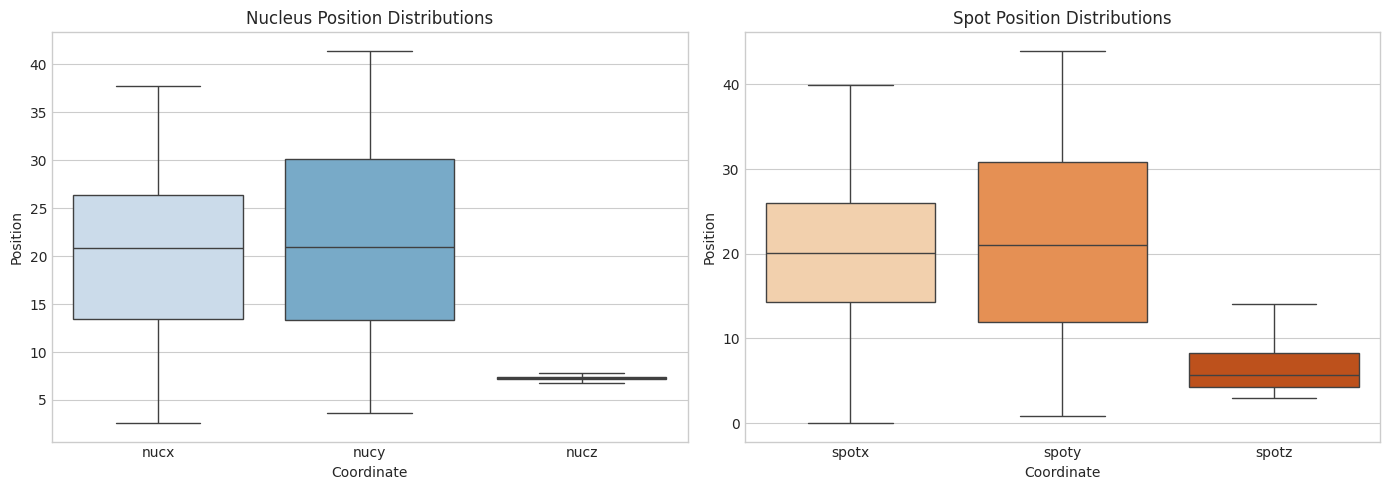

✅ Saved: ../results/intermediate_edgeSpotsRemoved/eda_position_boxplots.png


In [ ]:
# Box plots for position coordinates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nucleus positions
nuc_pos = df_wide[['nucx', 'nucy', 'nucz']].melt(var_name='Coordinate', value_name='Position')
sns.boxplot(data=nuc_pos, x='Coordinate', y='Position', ax=axes[0], palette='Blues')
axes[0].set_title('Nucleus Position Distributions')
axes[0].set_ylabel('Position')

# Spot positions
spot_pos = df_wide[['spotx', 'spoty', 'spotz']].melt(var_name='Coordinate', value_name='Position')
sns.boxplot(data=spot_pos, x='Coordinate', y='Position', ax=axes[1], palette='Oranges')
axes[1].set_title('Spot Position Distributions')
axes[1].set_ylabel('Position')

plt.tight_layout()
plt.show()

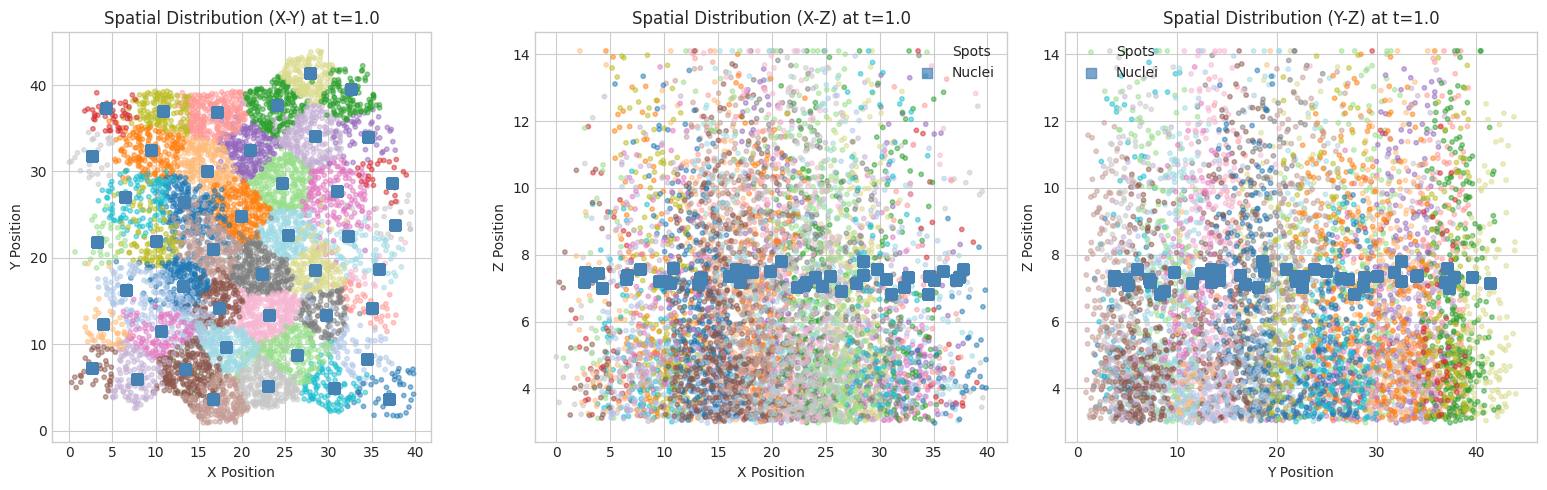

✅ Saved: ../results/intermediate_edgeSpotsRemoved/eda_spatial_distribution_2d.png


In [ ]:
# 2D spatial distribution: Spot positions (X-Y plane)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# X-Y plane
ax = axes[0]
sample_t = df_wide['time'].min()  # First time point
sample_data = df_wide[df_wide['time'] == sample_t]
# Shuffle the nucleus IDs to randomize color assignment
unique_nucs = sample_data['nuc'].unique()
shuffled_nucs = np.random.permutation(unique_nucs)
color_map = {nuc: i for i, nuc in enumerate(shuffled_nucs)}
colors = sample_data['nuc'].map(color_map)

# ax.scatter(sample_data['spotx'], sample_data['spoty'], alpha=0.5, s=10, c='darkorange', label='Spots')
ax.scatter(sample_data['spotx'], sample_data['spoty'], alpha=0.5, s=10, c=colors, cmap='tab20', label='Spots')
ax.scatter(sample_data['nucx'], sample_data['nucy'], alpha=0.7, s=50, c='steelblue', marker='s', label='Nuclei')
ax.set_xlabel('X Position')
ax.set_ylabel('Y Position')
ax.set_title(f'Spatial Distribution (X-Y) at t={sample_t:.1f}')
#ax.legend()
ax.set_aspect('equal')

# X-Z plane
ax = axes[1]
#ax.scatter(sample_data['spotx'], sample_data['spotz'], alpha=0.5, s=10, c='darkorange', label='Spots')
ax.scatter(sample_data['spotx'], sample_data['spotz'], alpha=0.5, s=10, c=colors, cmap='tab20', label='Spots')
ax.scatter(sample_data['nucx'], sample_data['nucz'], alpha=0.7, s=50, c='steelblue', marker='s', label='Nuclei')
ax.set_xlabel('X Position')
ax.set_ylabel('Z Position')
ax.set_title(f'Spatial Distribution (X-Z) at t={sample_t:.1f}')
ax.legend()

# Y-Z plane
ax = axes[2]
#ax.scatter(sample_data['spoty'], sample_data['spotz'], alpha=0.5, s=10, c='darkorange', label='Spots')
ax.scatter(sample_data['spoty'], sample_data['spotz'], alpha=0.5, s=10, c=colors, cmap='tab20', label='Spots')
ax.scatter(sample_data['nucy'], sample_data['nucz'], alpha=0.7, s=50, c='steelblue', marker='s', label='Nuclei')
ax.set_xlabel('Y Position')
ax.set_ylabel('Z Position')
ax.set_title(f'Spatial Distribution (Y-Z) at t={sample_t:.1f}')
ax.legend()

plt.tight_layout()
plt.show()

Number of nuclei: 45
Average k=4 NN distance (normalized): 0.169009
Std k=4 NN distance (normalized): 0.033529
Median k=4 NN distance (normalized): 0.163201


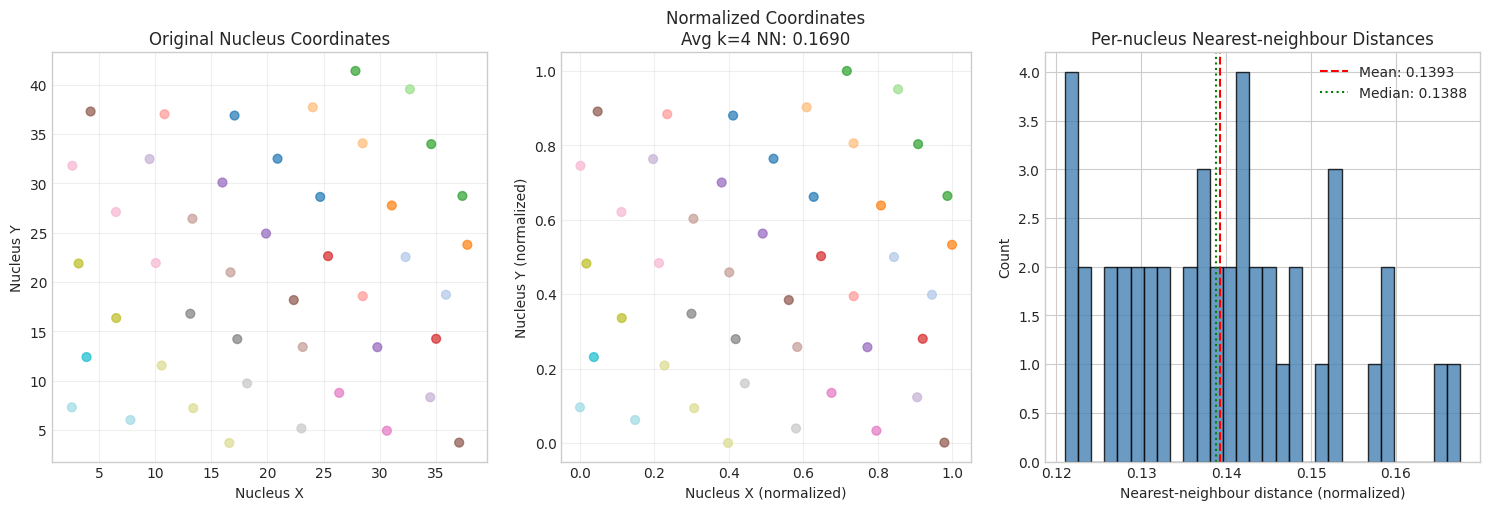

✅ Saved: ../results/intermediate_edgeSpotsRemoved/eda_nuclei_knn.png

SUMMARY: k-nearest neighbour distances (normalized coordinates)
 n_nuclei  k  avg_nn_distance  std_nn_distance  median_nn_distance
       45  4         0.169009         0.033529            0.163201


In [ ]:
from sklearn.neighbors import NearestNeighbors

# Use unique nuclei positions (already normalized in nuc_df)
points = nuc_df[['nucx_norm', 'nucy_norm']].values
k = 4

if points.shape[0] == 0:
    print('No nuclei found in nuc_df.')
else:
    n_neighbors = min(k + 1, points.shape[0])  # +1 to include self
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree').fit(points)
    distances, indices = nbrs.kneighbors(points)
    
    # Remove self-distance column if present
    distances_no_self = distances[:, 1:] if distances.shape[1] > 1 else np.empty((points.shape[0], 0))
    
    # Flatten distances for overall stats (ignore empty)
    flat = distances_no_self.ravel() if distances_no_self.size > 0 else np.array([])
    avg_distance = flat.mean() if flat.size > 0 else 0.0
    std_distance = flat.std() if flat.size > 0 else 0.0
    median_distance = np.median(flat) if flat.size > 0 else 0.0
    
    # Per-nucleus nearest-neighbour (exclude self)
    if distances_no_self.size > 0:
        per_nn = distances_no_self.min(axis=1)
    else:
        per_nn = np.zeros(points.shape[0])
    
    print(f'Number of nuclei: {points.shape[0]}')
    print(f'Average k={k} NN distance (normalized): {avg_distance:.6f}')
    print(f'Std k={k} NN distance (normalized): {std_distance:.6f}')
    print(f'Median k={k} NN distance (normalized): {median_distance:.6f}')
    
    # Results dataframe (single "dataset" since no embryo grouping available)
    results = [{
        'n_nuclei': points.shape[0],
        'k': k,
        'avg_nn_distance': avg_distance,
        'std_nn_distance': std_distance,
        'median_nn_distance': median_distance
    }]
    results_df = pd.DataFrame(results)
    
    # Plot original vs normalized coordinates and histogram of per-nucleus NN distances
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].scatter(nuc_df['nucx'], nuc_df['nucy'], c=nuc_df['nuc'], cmap='tab20', s=40, alpha=0.7)
    axes[0].set_xlabel('Nucleus X')
    axes[0].set_ylabel('Nucleus Y')
    axes[0].set_title('Original Nucleus Coordinates')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].scatter(nuc_df['nucx_norm'], nuc_df['nucy_norm'], c=nuc_df['nuc'], cmap='tab20', s=40, alpha=0.7)
    axes[1].set_xlabel('Nucleus X (normalized)')
    axes[1].set_ylabel('Nucleus Y (normalized)')
    axes[1].set_title(f'Normalized Coordinates\nAvg k={k} NN: {avg_distance:.4f}')
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].hist(per_nn, bins=30, color='steelblue', edgecolor='k', alpha=0.8)
    axes[2].set_xlabel('Nearest-neighbour distance (normalized)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('Per-nucleus Nearest-neighbour Distances')
    axes[2].axvline(per_nn.mean(), color='red', linestyle='--', label=f'Mean: {per_nn.mean():.4f}')
    axes[2].axvline(np.median(per_nn), color='green', linestyle=':', label=f'Median: {np.median(per_nn):.4f}')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print('\n' + '='*60)
    print('SUMMARY: k-nearest neighbour distances (normalized coordinates)')
    print('='*60)
    print(results_df.to_string(index=False))
    print('='*60)

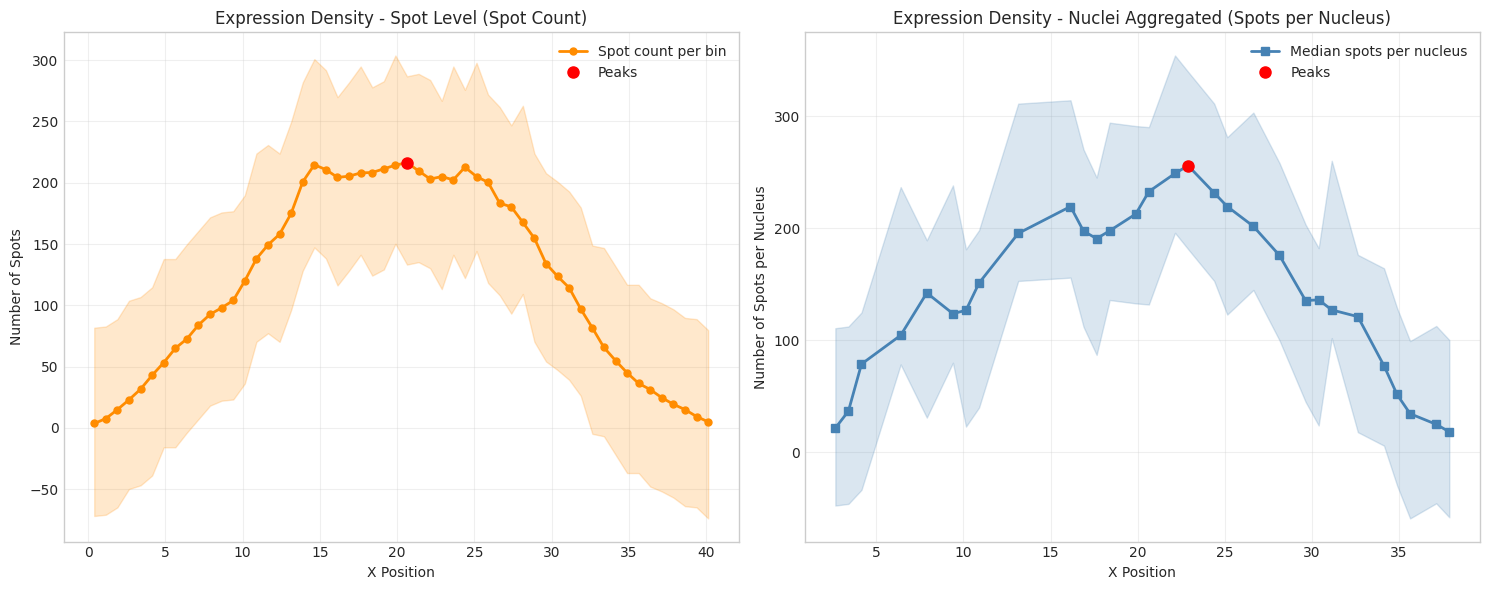

✅ Saved: ../results/intermediate_edgeSpotsRemoved/expression_density_x_axis.png

EXPRESSION DENSITY SUMMARY

Spot-level analysis:
  - Number of bins: 54
  - Total spots: 6512
  - Mean spots per bin: 120.59

Nuclei-aggregated analysis:
  - Number of bins: 30
  - Total nuclei analyzed: 45
  - Median spots per nucleus: 158.25


In [ ]:
# Spatial expression density analysis across X-axis
# Two approaches: spot-level and nuclei-aggregated

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ============================================
# APPROACH 1: Spot-level expression density
# ============================================
# Use spot counts binned across X-axis

# Define bins across X-axis
min_x = df_wide['spotx'].min()
max_x = df_wide['spotx'].max()
BIN_SIZE = 0.75  # Adjust bin size as needed
bins = np.arange(min_x, max_x + BIN_SIZE, BIN_SIZE)
df_wide['x_bin'] = pd.cut(df_wide['spotx'], bins)

# Calculate median spot count per bin
spot_density = df_wide.groupby('x_bin').size().reset_index(name='spot_count')
spot_density['x_bin_center'] = spot_density['x_bin'].apply(lambda x: x.mid)
spot_density = spot_density.dropna()

# Smooth using moving average
window = 3
spot_density['spot_count_smooth'] = np.convolve(spot_density['spot_count'], np.ones(window)/window, mode='same')

# Find peaks in the smoothed data
import scipy.signal as signal
peaks, _ = signal.find_peaks(spot_density['spot_count_smooth'].values, prominence=200)  # Adjust prominence as needed

# Plot spot-level density
ax = axes[0]
ax.plot(spot_density['x_bin_center'].values, spot_density['spot_count_smooth'].values, 
    'o-', linewidth=2, markersize=5, color='darkorange', label='Spot count per bin')
ax.fill_between(spot_density['x_bin_center'].values, 
        (spot_density['spot_count'] - spot_density['spot_count'].std()).values, 
        (spot_density['spot_count'] + spot_density['spot_count'].std()).values, 
        alpha=0.2, color='darkorange')
# Use positional indexing (.iloc) / numpy .values so peak positions map correctly
ax.plot(spot_density['x_bin_center'].iloc[peaks].values, spot_density['spot_count_smooth'].iloc[peaks].values, 'ro', markersize=8, label='Peaks')
ax.set_xlabel('X Position')
ax.set_ylabel('Number of Spots')
ax.set_title('Expression Density - Spot Level (Spot Count)')
ax.grid(True, alpha=0.3)
ax.legend()

# ============================================
# APPROACH 2: Nuclei-aggregated density
# ============================================
# Count spots per nucleus, then bin nuclei across X-axis

# Count spots per nucleus
nuc_spot_count = df_wide.groupby(['nuc', 'nucx']).size().reset_index(name='spot_count')

# Bin nuclei across X-axis
nuc_spot_count['x_bin'] = pd.cut(nuc_spot_count['nucx'], bins)

# Calculate median spot count per bin (nuclei level)
nuc_density = nuc_spot_count.groupby('x_bin')['spot_count'].agg(['median', 'mean', 'count']).reset_index()
nuc_density['x_bin_center'] = nuc_density['x_bin'].apply(lambda x: x.mid)
nuc_density = nuc_density.dropna()
# Smooth nuclei-level density
nuc_density['median_smooth'] = np.convolve(nuc_density['median'].values, np.ones(window)/window, mode='same')

# Find peaks in the smoothed data (signal already imported above)
peaks, _ = signal.find_peaks(nuc_density['median_smooth'], prominence=200)  # Adjust prominence as needed

# Plot nuclei-aggregated density
ax = axes[1]
ax.plot(nuc_density['x_bin_center'].values, nuc_density['median_smooth'], 
    's-', linewidth=2, markersize=6, color='steelblue', label='Median spots per nucleus')
ax.fill_between(nuc_density['x_bin_center'].values, 
        (nuc_density['median'] - nuc_density['median'].std()).values, 
        (nuc_density['median'] + nuc_density['median'].std()).values, 
        alpha=0.2, color='steelblue')
# Use positional indexing (.iloc) / numpy .values so peak positions map correctly
ax.plot(nuc_density['x_bin_center'].iloc[peaks].values, nuc_density['median_smooth'].iloc[peaks].values, 'ro', markersize=8, label='Peaks')
ax.set_xlabel('X Position')
ax.set_ylabel('Number of Spots per Nucleus')
ax.set_title('Expression Density - Nuclei Aggregated (Spots per Nucleus)')
ax.grid(True, alpha=0.3)
ax.legend()
ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("EXPRESSION DENSITY SUMMARY")
print("="*60)
print(f"\nSpot-level analysis:")
print(f"  - Number of bins: {len(spot_density)}")
print(f"  - Total spots: {spot_density['spot_count'].sum():.0f}")
print(f"  - Mean spots per bin: {spot_density['spot_count'].mean():.2f}")

print(f"\nNuclei-aggregated analysis:")
print(f"  - Number of bins: {len(nuc_density)}")
print(f"  - Total nuclei analyzed: {nuc_density['count'].sum():.0f}")
print(f"  - Median spots per nucleus: {nuc_density['median'].median():.2f}")
# reason for different number of bins: They share the same bin edges but not the same data density: approach 1 bins every spot (many spots → many occupied bins), approach 2 bins one row per nucleus (far fewer nuclei → many bins empty). groupby only returns bins that contain data, so spot-level shows ~80 occupied bins while nucleus-aggregated shows ~34 occupied bins. dropna()/aggregation can further remove empty/NaN bins.

## 6. Time Series Analysis of Position Data

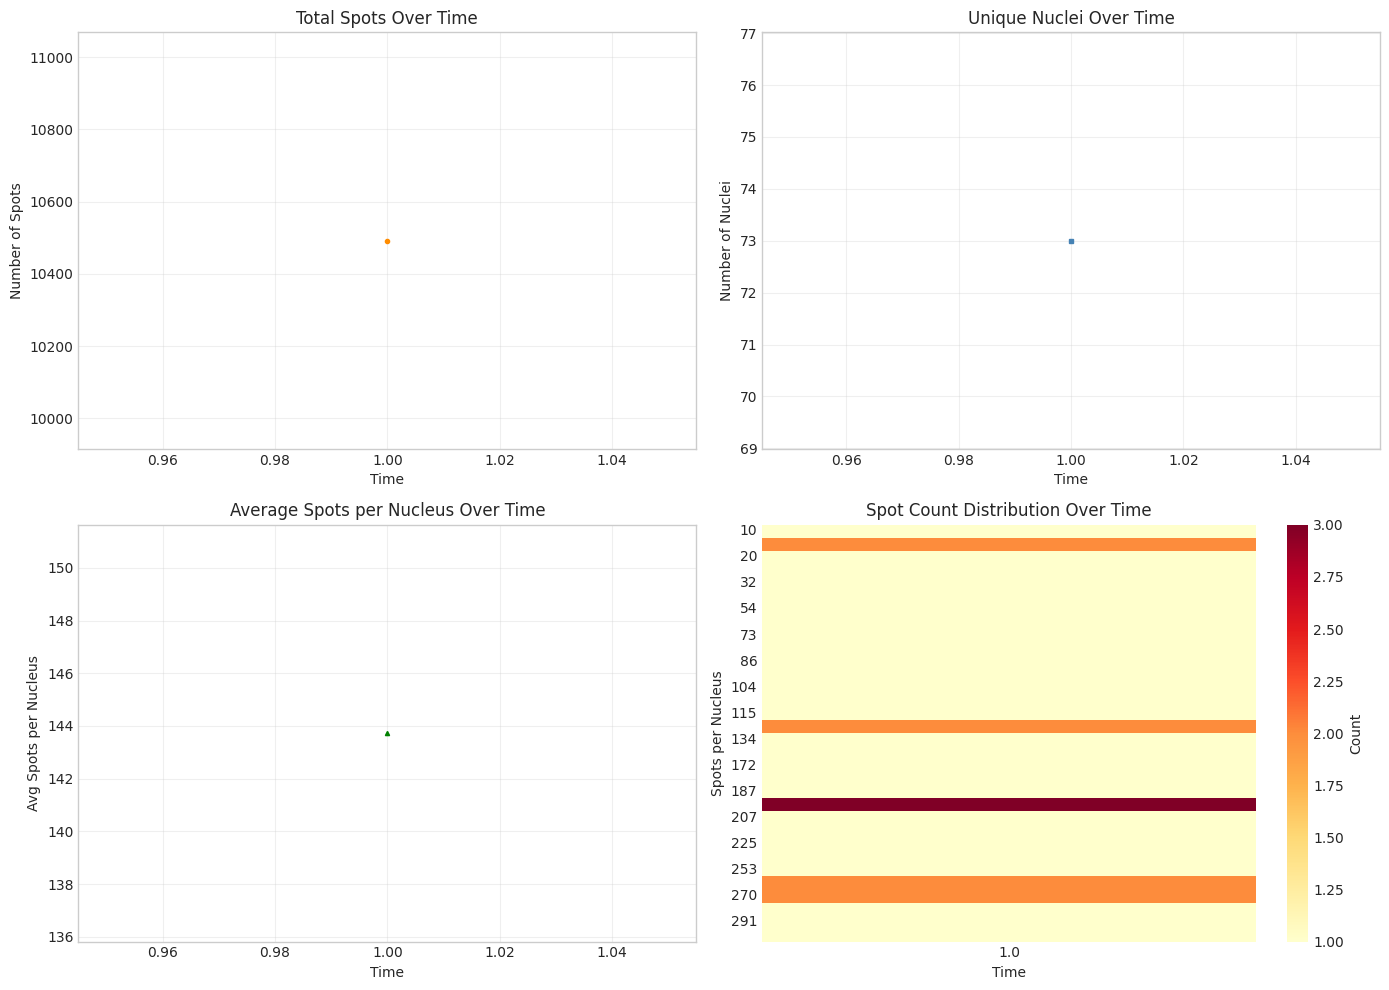

✅ Saved: ../results/intermediate/eda_temporal_analysis.png


In [ ]:
# Temporal analysis: spots and nuclei over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Number of spots over time
spots_per_time = df_wide.groupby('time').size()
ax = axes[0, 0]
ax.plot(spots_per_time.index, spots_per_time.values, 'o-', linewidth=1, markersize=3, color='darkorange')
ax.set_xlabel('Time')
ax.set_ylabel('Number of Spots')
ax.set_title('Total Spots Over Time')
ax.grid(True, alpha=0.3)

# Number of nuclei over time
nuclei_per_time = df_wide.groupby('time')['nuc'].nunique()
ax = axes[0, 1]
ax.plot(nuclei_per_time.index, nuclei_per_time.values, 's-', linewidth=1, markersize=3, color='steelblue')
ax.set_xlabel('Time')
ax.set_ylabel('Number of Nuclei')
ax.set_title('Unique Nuclei Over Time')
ax.grid(True, alpha=0.3)

# Average spots per nucleus over time
avg_spots_per_nuc = df_wide.groupby('time').apply(lambda x: x.groupby('nuc').size().mean())
ax = axes[1, 0]
ax.plot(avg_spots_per_nuc.index, avg_spots_per_nuc.values, '^-', linewidth=1, markersize=3, color='green')
ax.set_xlabel('Time')
ax.set_ylabel('Avg Spots per Nucleus')
ax.set_title('Average Spots per Nucleus Over Time')
ax.grid(True, alpha=0.3)

# Distribution of spot counts over time (heatmap)
ax = axes[1, 1]
spot_count_dist = df_wide.groupby(['time', 'nuc'])['num_spots'].first().reset_index()
time_spot_pivot = spot_count_dist.pivot_table(index='time', columns='num_spots', aggfunc='size', fill_value=0)
# Subsample if too many columns
if time_spot_pivot.shape[1] > 30:
    time_spot_pivot = time_spot_pivot.iloc[:, ::2]
sns.heatmap(time_spot_pivot.T, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_xlabel('Time')
ax.set_ylabel('Spots per Nucleus')
ax.set_title('Spot Count Distribution Over Time')

plt.tight_layout()
plt.show()

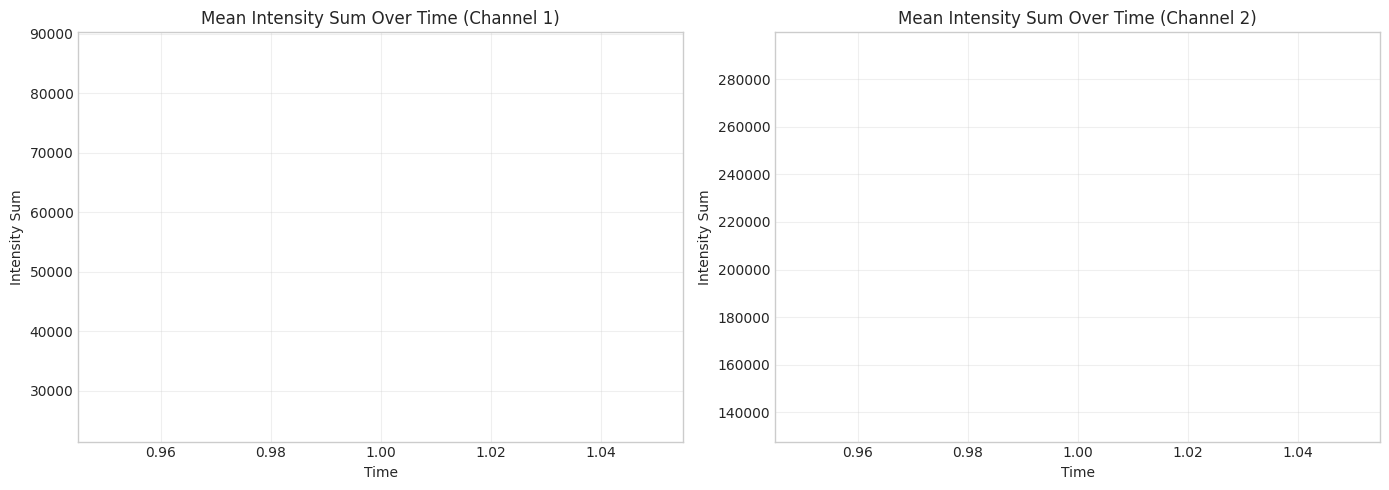

✅ Saved: ../results/intermediate/eda_intensity_temporal.png


In [ ]:
# Intensity Sum over time (for channel 1 and 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter for Intensity Sum variable
intensity_sum = df[df['variable'] == 'Intensity Sum'].copy()

for i, channel in enumerate([1, 2]):
    ch_data = intensity_sum[intensity_sum['channel'] == channel]
    ch_stats = ch_data.groupby('time')['value'].agg(['mean', 'std'])
    
    ax = axes[i]
    ax.fill_between(ch_stats.index, 
                    ch_stats['mean'] - ch_stats['std'], 
                    ch_stats['mean'] + ch_stats['std'], 
                    alpha=0.3)
    ax.plot(ch_stats.index, ch_stats['mean'], '-', linewidth=2)
    ax.set_xlabel('Time')
    ax.set_ylabel('Intensity Sum')
    ax.set_title(f'Mean Intensity Sum Over Time (Channel {channel})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

STRONG CORRELATIONS (|r| > 0.7)
  nucx ↔ spotx: r = 0.982
  nucy ↔ spoty: r = 0.992


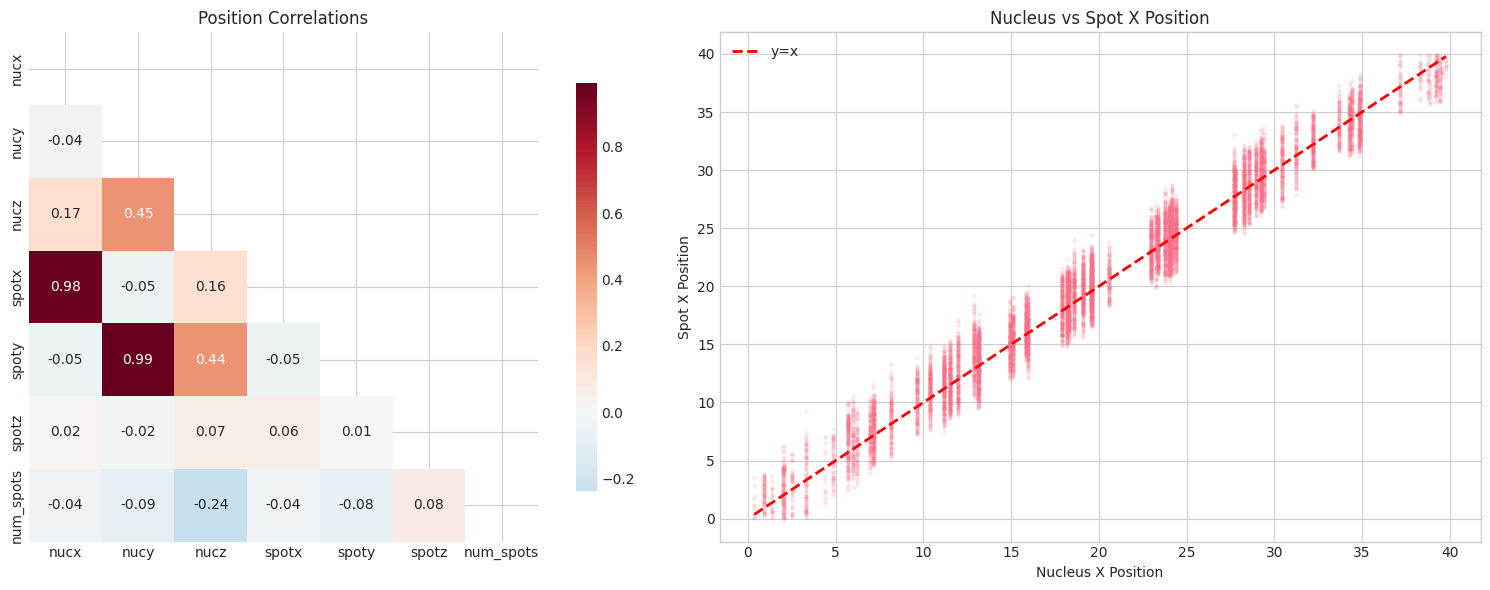


✅ Saved: ../results/intermediate/eda_correlations.png


In [ ]:
# Correlation matrix for position variables
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Position correlations (nucleus vs spot)
position_cols_all = ['nucx', 'nucy', 'nucz', 'spotx', 'spoty', 'spotz', 'num_spots']
corr_matrix = df_wide[position_cols_all].corr()

ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Position Correlations')

# Identify strong correlations
print("="*60)
print("STRONG CORRELATIONS (|r| > 0.7)")
print("="*60)
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            strong_corr.append({
                'var1': corr_matrix.columns[i],
                'var2': corr_matrix.columns[j],
                'r': r
            })
            
if strong_corr:
    for c in strong_corr:
        print(f"  {c['var1']} ↔ {c['var2']}: r = {c['r']:.3f}")
else:
    print("  No strong correlations found")

# Scatter plot of nucleus vs spot positions (X coordinate)
ax = axes[1]
ax.scatter(df_wide['nucx'], df_wide['spotx'], alpha=0.1, s=5)
ax.plot([df_wide['nucx'].min(), df_wide['nucx'].max()], 
        [df_wide['nucx'].min(), df_wide['nucx'].max()], 
        'r--', linewidth=2, label='y=x')
ax.set_xlabel('Nucleus X Position')
ax.set_ylabel('Spot X Position')
ax.set_title('Nucleus vs Spot X Position')
ax.legend()

plt.tight_layout()
plt.show()

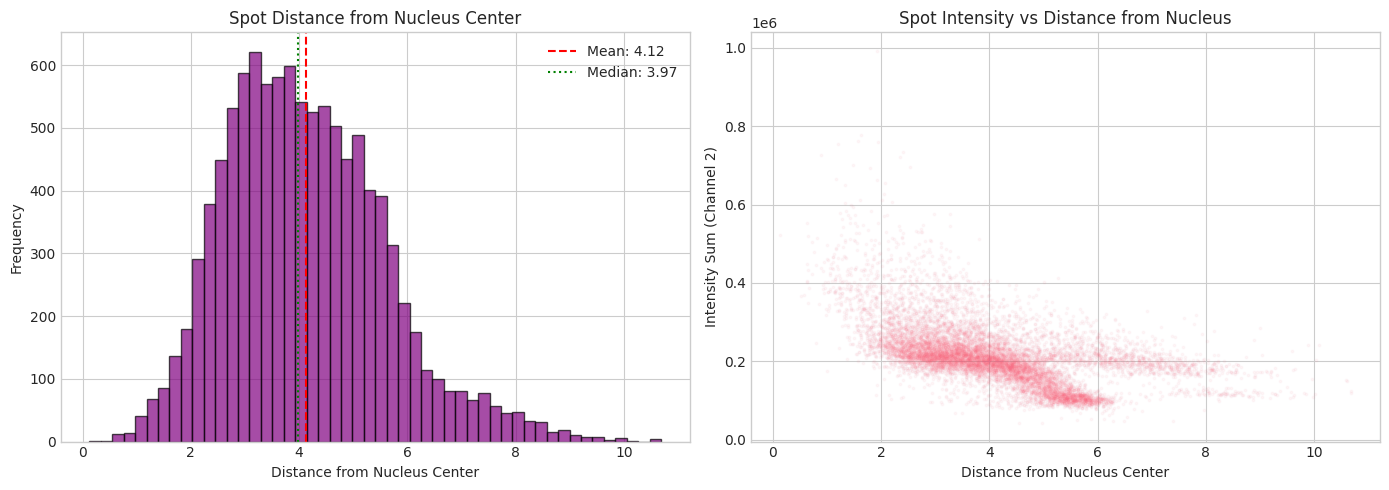

✅ Saved: ../results/intermediate/eda_spot_nucleus_distance.png


In [ ]:
# Spot distance from nucleus center
df_wide['spot_nuc_dist'] = np.sqrt(
    (df_wide['spotx'] - df_wide['nucx'])**2 + 
    (df_wide['spoty'] - df_wide['nucy'])**2 + 
    (df_wide['spotz'] - df_wide['nucz'])**2
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of distances
ax = axes[0]
ax.hist(df_wide['spot_nuc_dist'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='purple')
ax.axvline(df_wide['spot_nuc_dist'].mean(), color='red', linestyle='--', 
           label=f"Mean: {df_wide['spot_nuc_dist'].mean():.2f}")
ax.axvline(df_wide['spot_nuc_dist'].median(), color='green', linestyle=':', 
           label=f"Median: {df_wide['spot_nuc_dist'].median():.2f}")
ax.set_xlabel('Distance from Nucleus Center')
ax.set_ylabel('Frequency')
ax.set_title('Spot Distance from Nucleus Center')
ax.legend()

# Distance vs intensity
ax = axes[1]
# Get intensity sum for channel 2 (usually mRNA signal)
if ('Intensity Sum', 2) in df_wide.columns or 'Intensity Sum_2' in df_wide.columns:
    try:
        intensity_col = df_wide[('Intensity Sum', 2)]
    except:
        intensity_col = df_wide['Intensity Sum_2'] if 'Intensity Sum_2' in df_wide.columns else None
    
    if intensity_col is not None:
        ax.scatter(df_wide['spot_nuc_dist'], intensity_col, alpha=0.05, s=3)
        ax.set_xlabel('Distance from Nucleus Center')
        ax.set_ylabel('Intensity Sum (Channel 2)')
        ax.set_title('Spot Intensity vs Distance from Nucleus')
else:
    ax.text(0.5, 0.5, 'Intensity columns not found', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()

## 8. Detect Outliers and Anomalies

In [18]:
def detect_outliers_iqr(data, column):
    """Detect outliers using IQR method."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

print("="*60)
print("OUTLIER DETECTION (IQR Method)")
print("="*60)

outlier_summary = []
for col in position_cols + ['spot_nuc_dist']:
    if col in df_wide.columns:
        outliers, lower, upper = detect_outliers_iqr(df_wide, col)
        n_outliers = len(outliers)
        pct = n_outliers / len(df_wide) * 100
        outlier_summary.append({
            'Variable': col,
            'N Outliers': n_outliers,
            'Percent': f'{pct:.2f}%',
            'Lower Bound': f'{lower:.2f}',
            'Upper Bound': f'{upper:.2f}'
        })

outlier_df = pd.DataFrame(outlier_summary)
print("\n")
print(outlier_df.to_string(index=False))

OUTLIER DETECTION (IQR Method)


     Variable  N Outliers Percent Lower Bound Upper Bound
         nucx           0   0.00%       -8.77       49.64
         nucy           0   0.00%      -26.91       71.34
         nucz         295   2.81%        5.75        7.63
        spotx           0   0.00%       -6.05       46.82
        spoty           0   0.00%      -24.74       69.30
        spotz           0   0.00%       -4.94       16.01
spot_nuc_dist         152   1.45%       -0.01        8.11


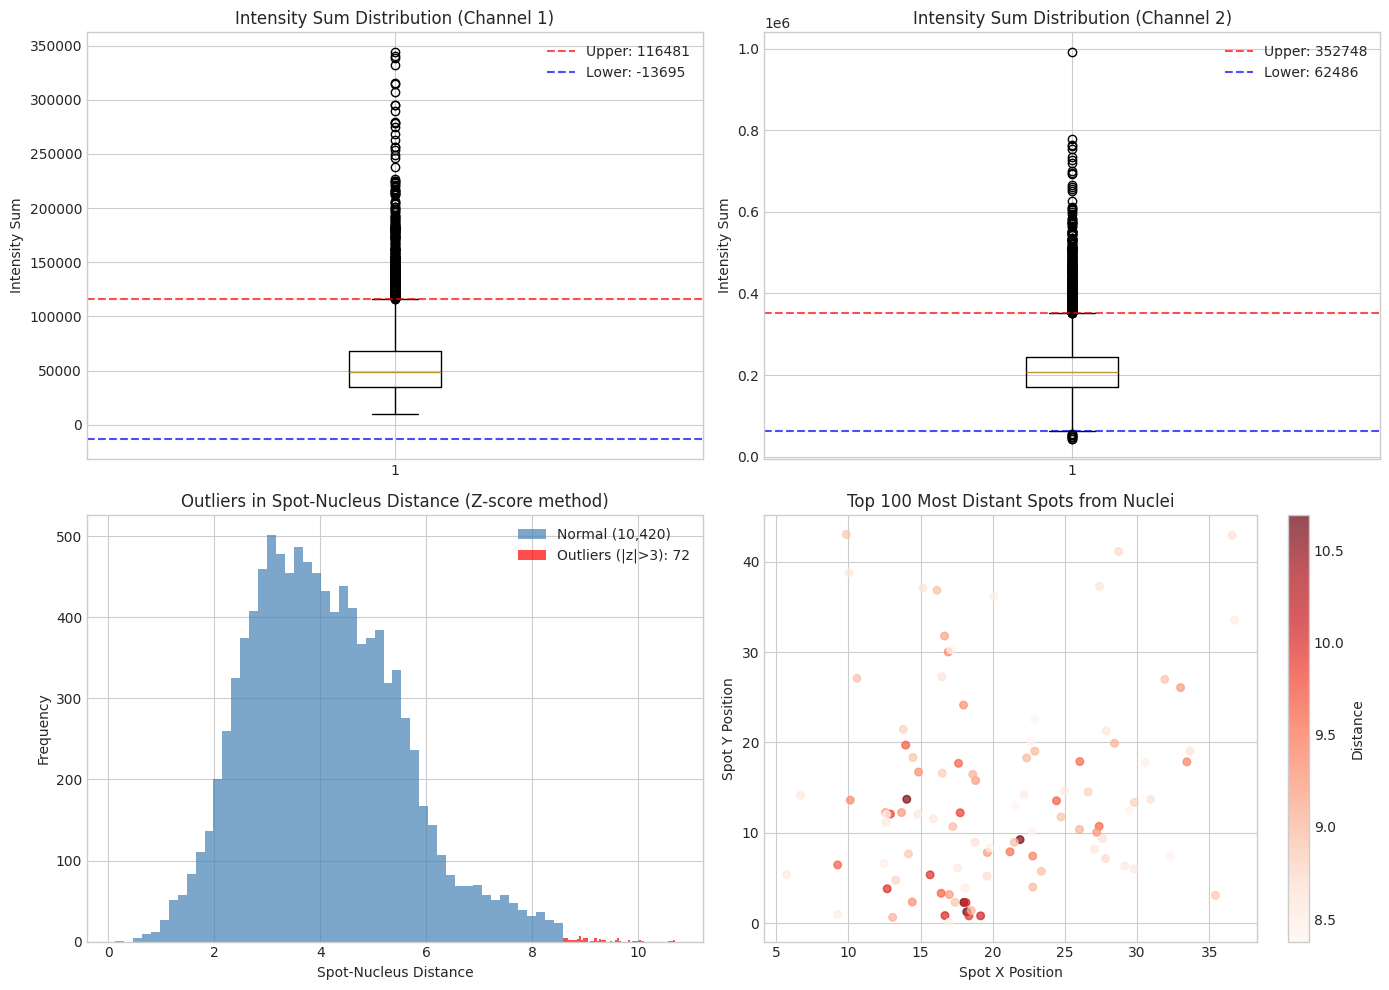

✅ Saved: ../results/intermediate/eda_outliers.png


In [ ]:
# Visualize outliers for intensity values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Intensity Sum outliers by channel
for i, channel in enumerate([1, 2]):
    ch_data = df[df['channel'] == channel]
    intensity_sum_data = ch_data[ch_data['variable'] == 'Intensity Sum']['value']
    
    ax = axes[0, i]
    ax.boxplot(intensity_sum_data.dropna(), vert=True)
    ax.set_ylabel('Intensity Sum')
    ax.set_title(f'Intensity Sum Distribution (Channel {channel})')
    
    # Print outlier stats
    outliers, lower, upper = detect_outliers_iqr(ch_data[ch_data['variable'] == 'Intensity Sum'], 'value')
    ax.axhline(upper, color='red', linestyle='--', alpha=0.7, label=f'Upper: {upper:.0f}')
    ax.axhline(lower, color='blue', linestyle='--', alpha=0.7, label=f'Lower: {lower:.0f}')
    ax.legend()

# Z-score based outliers for spot positions
from scipy import stats

ax = axes[1, 0]
z_scores = np.abs(stats.zscore(df_wide['spot_nuc_dist'].dropna()))
outlier_mask = z_scores > 3
ax.hist(df_wide['spot_nuc_dist'].dropna()[~outlier_mask], bins=50, alpha=0.7, 
        label=f'Normal ({sum(~outlier_mask):,})', color='steelblue')
ax.hist(df_wide['spot_nuc_dist'].dropna()[outlier_mask], bins=50, alpha=0.7, 
        label=f'Outliers (|z|>3): {sum(outlier_mask):,}', color='red')
ax.set_xlabel('Spot-Nucleus Distance')
ax.set_ylabel('Frequency')
ax.set_title('Outliers in Spot-Nucleus Distance (Z-score method)')
ax.legend()

# Spots with unusually high distance from nucleus
ax = axes[1, 1]
extreme_dist = df_wide.nlargest(100, 'spot_nuc_dist')
ax.scatter(extreme_dist['spotx'], extreme_dist['spoty'], c=extreme_dist['spot_nuc_dist'], 
           cmap='Reds', s=30, alpha=0.7)
ax.set_xlabel('Spot X Position')
ax.set_ylabel('Spot Y Position')
ax.set_title('Top 100 Most Distant Spots from Nuclei')
plt.colorbar(ax.collections[0], ax=ax, label='Distance')

plt.tight_layout()
plt.show()

## 9. Summary and Key Findings

In [ ]:
# Generate EDA summary report
print("="*70)
print("EXPLORATORY DATA ANALYSIS SUMMARY REPORT")
print("="*70)
print(f"\n📁 Dataset: position_data-intense.txt (Embryo 1)")
print(f"📅 Analysis Date: 2024-12-16")

print("\n" + "-"*70)
print("1. DATA OVERVIEW")
print("-"*70)
print(f"   • Total rows (long format): {len(df):,}")
print(f"   • Total spots (unique): {df_wide.shape[0]:,}")
print(f"   • Columns: {df.shape[1]}")
print(f"   • Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "-"*70)
print("2. STRUCTURE")  
print("-"*70)
print(f"   • Time range: {df['time'].min():.1f} - {df['time'].max():.1f}")
print(f"   • Time points: {df['time'].nunique()}")
print(f"   • Unique nuclei: {df['nuc'].nunique()}")
print(f"   • Unique spots: {df['spot'].nunique()}")
print(f"   • Channels: {sorted(df['channel'].unique())}")
print(f"   • Intensity measures: {list(df['variable'].unique())}")

print("\n" + "-"*70)
print("3. DATA QUALITY")
print("-"*70)
print(f"   • Missing values: {df.isnull().sum().sum()} ({df.isnull().sum().sum()/df.size*100:.4f}%)")
print(f"   • Duplicate rows: {df.duplicated().sum()}")

print("\n" + "-"*70)
print("4. KEY STATISTICS")
print("-"*70)
print(f"   • Avg spots per nucleus: {df_wide.groupby(['time', 'nuc']).size().mean():.1f}")
print(f"   • Avg spot-nucleus distance: {df_wide['spot_nuc_dist'].mean():.2f}")
print(f"   • Max spot-nucleus distance: {df_wide['spot_nuc_dist'].max():.2f}")

print("\n" + "="*70)
print("EDA COMPLETE!")
print("="*70)

EXPLORATORY DATA ANALYSIS SUMMARY REPORT

📁 Dataset: position_data-intense.txt (Embryo 1)
📅 Analysis Date: 2024-12-16

----------------------------------------------------------------------
1. DATA OVERVIEW
----------------------------------------------------------------------
   • Total rows (long format): 167,872
   • Total spots (unique): 10,492
   • Columns: 14
   • Memory: 37.22 MB

----------------------------------------------------------------------
2. STRUCTURE
----------------------------------------------------------------------
   • Time range: 1.0 - 1.0
   • Time points: 1
   • Unique nuclei: 73
   • Unique spots: 10492
   • Channels: [1, 2]
   • Intensity measures: ['Intensity Sum', 'Intensity Sum of Square', 'Intensity Max', 'Intensity Median', 'Intensity Center', 'Intensity Mean', 'Intensity StdDev', 'Intensity Min']

----------------------------------------------------------------------
3. DATA QUALITY
-------------------------------------------------------------------

---

## 📝 Recommendations and Next Steps

Based on this exploratory analysis:

1. **Data Quality**: 
   - Check for any missing values if detected
   - Investigate duplicate spot-time combinations if found
   - Consider filtering spots with extreme distances from nuclei

2. **Further Analysis**:
   - `/statistical_analysis` - Formal hypothesis testing for intensity differences
   - `/scientific_visualization` - Publication-ready figures
   - Track spot dynamics over time within individual nuclei

3. **Model Considerations**:
   - The spot-nucleus distance distribution may inform spatial models
   - Intensity channels may need normalization before comparison
   - Consider the temporal autocorrelation structure for time-series modeling

---
*EDA generated using the Research Assistant exploratory-data-analysis skill*